In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler

!pip install pmdarima
from pmdarima import auto_arima

# importing util
import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

print('finished imports!')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 6.0 MB/s eta 0:00:00
finished imports!


In [ ]:
monthly_all_df = pd.read_csv('/content/drive/MyDrive/DSSI/Project/code/monthly_dataset.csv', parse_dates=['Year-Month'])
monthly_all_df['diff_rate_per_100k'] = monthly_all_df['rate_per_100k'].diff()
monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)
monthly_all_df

/tmp/ipykernel_2141/3256535164.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)
/tmp/ipykernel_2141/3256535164.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)


,Year-Month,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k,diff_rate_per_100k
0,2001-01-01,3.297857,68.875000,3.522294,2618.515476,0.071429,50.526140,90.4375,40.5000,NaN,4395.45360,633.69475,1.047661,-0.422359
1,2001-02-01,4.035595,72.722462,3.916194,2586.921429,0.166667,52.125481,58.8750,19.6875,NaN,9071.70725,813.86195,0.625301,-0.422359
2,2001-03-01,1.575238,75.960526,3.718078,2731.164286,0.261905,59.033824,64.8125,31.5000,NaN,17723.88265,1338.29970,0.590922,-0.034380
3,2001-04-01,0.996429,69.248725,4.151603,2970.052381,0.047619,61.664271,53.6250,26.6875,NaN,33417.33930,1220.31340,0.389830,-0.201092
4,2001-05-01,0.140476,65.798855,4.007988,2980.953571,0.214286,69.491572,65.1875,39.1250,NaN,22334.85285,1341.28055,0.936698,0.546868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2024-08-01,0.544191,55.632990,3.595854,2674.035376,0.034091,77.821805,56.0000,39.2500,52890.0,NaN,NaN,9.684514,1.282228
284,2024-09-01,0.263324,58.514057,3.270548,2349.681507,0.056818,75.303352,55.0625,41.2500,76615.5,NaN,NaN,10.127484,0.442970
285,2024-10-01,0.179034,57.233556,3.168064,2328.647200,0.116883,69.680384,59.3750,49.0000,1021.0,NaN,NaN,11.848059,1.720575
286,2024-11-01,0.845889,59.086648,3.398240,2445.109186,0.295996,58.672030,56.1250,34.0000,2574.5,NaN,NaN,11.813999,-0.034061


In [ ]:
X = monthly_all_df[['AQI_PM10']]
y = monthly_all_df['rate_per_100k']

In [ ]:
TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

test_dates = monthly_all_df["Year-Month"].iloc[split:]

In [ ]:
# auto ARIMA to find the best parameters
auto_model = auto_arima(y_train, exogenous=X_train, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.67 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=711.959, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=672.355, Time=0.16 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=682.043, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=710.064, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=706.210, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=672.361, Time=0.39 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=680.278, Time=0.14 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=4.94 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=677.155, Time=0.49 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=672.187, Time=0.63 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=702.795, Time=0.12 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=672.058, Time=1.17 sec
 ARIMA(2,1,0)(2,0,1)[12] intercept   : AIC=in

In [ ]:
print(auto_model.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  230
Model:             SARIMAX(4, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood                -306.664
Date:                                 Mon, 06 Jul 2026   AIC                            633.328
Time:                                         14:37:43   BIC                            667.665
Sample:                                              0   HQIC                           647.180
                                                 - 230                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0005      0.001      0.382      0.702      -0.002       0

In [ ]:
print("Best model params:", auto_model.order, auto_model.seasonal_order)

Best model params: (4, 1, 1) (1, 0, 2, 12)


In [ ]:
# sarima model to predict VF rate
# exog=AQI_10
# order=(4,1,1)
# seasonal_order=(1,0,2,12)

sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    trend='n',
    order=(4,1,1),
    seasonal_order=(1,0,2,12)
)

results = sarimax_model.fit()
print(results.summary())

                                        SARIMAX Results                                        
Dep. Variable:                           rate_per_100k   No. Observations:                  230
Model:             SARIMAX(4, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood                -305.717
Date:                                 Mon, 06 Jul 2026   AIC                            631.435
Time:                                         14:41:31   BIC                            665.772
Sample:                                              0   HQIC                           645.287
                                                 - 230                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
AQI_PM10       0.0095      0.009      1.044      0.296      -0.008       0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# sarima model to predict VF rate
# exog=AQI_10
# order=(12,1,2)

sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    trend='n',
    order=(12,1,2)
)

results = sarimax_model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:          rate_per_100k   No. Observations:                  230
Model:              SARIMAX(12, 1, 2)   Log Likelihood                -302.282
Date:                Thu, 02 Jul 2026   AIC                            636.564
Time:                        18:55:47   BIC                            691.503
Sample:                             0   HQIC                           658.728
                                - 230                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
AQI_PM10       0.0161      0.008      1.991      0.046       0.000       0.032
ar.L1         -0.3579      0.650     -0.551      0.582      -1.631       0.915
ar.L2         -0.1844      0.317     -0.581      0.5

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast = results.get_forecast(steps=len(y_test), exog=X_test)

y_pred = forecast.predicted_mean

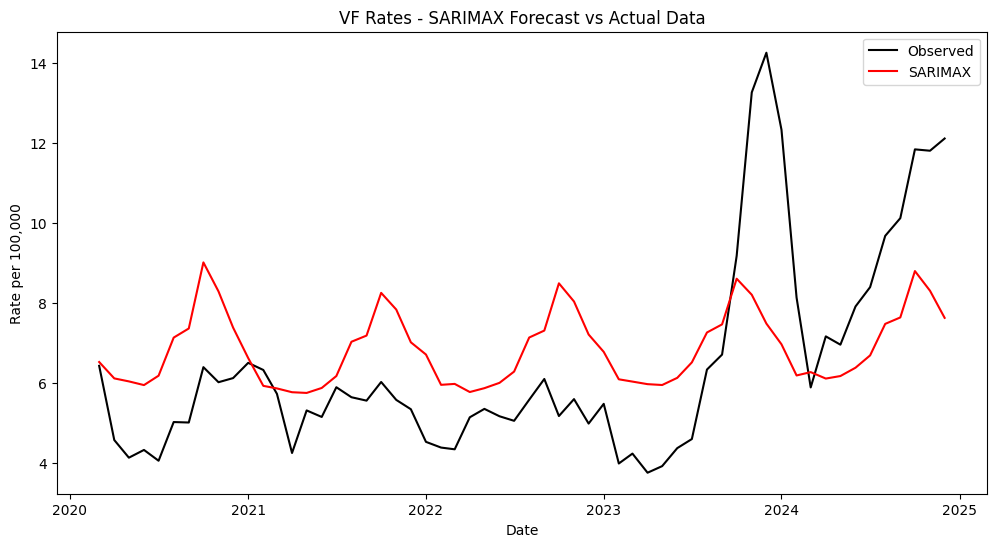

Model                           RMSE=2.22454   MAE=1.82385
{'RMSE': np.float64(2.2245387194965507), 'MAE': 1.8238522028754414}


In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test, label="Observed", color="black")
plt.plot(test_dates, y_pred, label="SARIMAX", color="red")

plt.title("VF Rates - SARIMAX Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

print(utils.compute_metrics(y_test, y_pred))

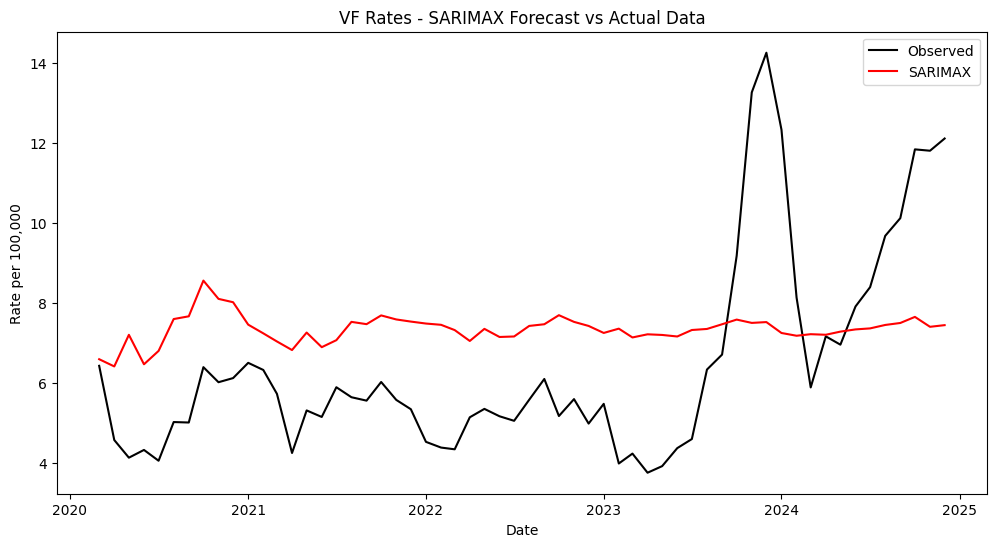

Model                           RMSE=2.61729   MAE=2.28299
{'RMSE': np.float64(2.6172890573534566), 'MAE': 2.2829899176131154}


In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test, label="Observed", color="black")
plt.plot(test_dates, y_pred, label="SARIMAX", color="red")

plt.title("VF Rates - SARIMAX Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

print(utils.compute_metrics(y_test, y_pred))

In [ ]:
# SARIMAX model using all exogenous variables except fire, fungicide, rodent

In [ ]:
X = monthly_all_df.drop(columns=['Year-Month','rate_per_100k','diff_rate_per_100k','FIRE_Acres_Burned','fungicide_lbs_prd_used', 'rodent_lbs_prd_used'])
y = np.log1p(monthly_all_df['rate_per_100k']) # using the log1p of the target variable

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

# Scale the features and target variable
# scaler_X = MinMaxScaler()
# X_scaled = scaler_X.fit_transform(X) #fix

# X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X_scaled, y)
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

test_dates = monthly_all_df["Year-Month"].iloc[split:]

In [ ]:
# auto ARIMA to find the best parameters
auto_model = auto_arima(y_train, exogenous=X_train, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)
order = auto_model.order
seasonal_order = auto_model.seasonal_order

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=4.14 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-89.981, Time=0.20 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-118.904, Time=0.95 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-109.783, Time=2.07 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-91.787, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-90.769, Time=0.25 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=-121.821, Time=5.39 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=5.12 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=-122.539, Time=0.69 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-118.773, Time=0.17 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=3.57 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.84 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-121.547, Time=1.13 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=-120

In [ ]:
print(auto_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  230
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 12)   Log Likelihood                  65.219
Date:                            Mon, 06 Jul 2026   AIC                           -124.438
Time:                                    18:16:47   BIC                           -114.137
Sample:                                         0   HQIC                          -120.282
                                            - 230                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.3082      0.066      4.691      0.000       0.179       0.437
ar.S.L24       0.1685      0.082   

In [ ]:
print("Best model params:", order, seasonal_order)

Best model params: (0, 1, 0) (2, 0, 0, 12)


In [ ]:
# sarima model to predict VF rate

sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    trend='n',
    order=(0,0,0),
    seasonal_order=seasonal_order
)

results = sarimax_model.fit()
print(results.summary())

                                SARIMAX Results                                 
Dep. Variable:            rate_per_100k   No. Observations:                  230
Model:             SARIMAX(2, 0, 0, 12)   Log Likelihood                -112.586
Date:                  Mon, 06 Jul 2026   AIC                            247.173
Time:                          19:00:36   BIC                            284.991
Sample:                               0   HQIC                           262.428
                                  - 230                                         
Covariance Type:                    opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Precipitation            0.0394      0.033      1.204      0.229      -0.025       0.103
Avg Rel Hum (%)          0.0086      0.005      1.696      0.090      -0.001       0.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast = results.get_forecast(steps=len(y_test), exog=X_test)
y_pred = forecast.predicted_mean

# Convert preds back to original scale
y_pred_original = np.expm1(y_pred)

y_test_original = monthly_all_df['rate_per_100k'].iloc[split:]

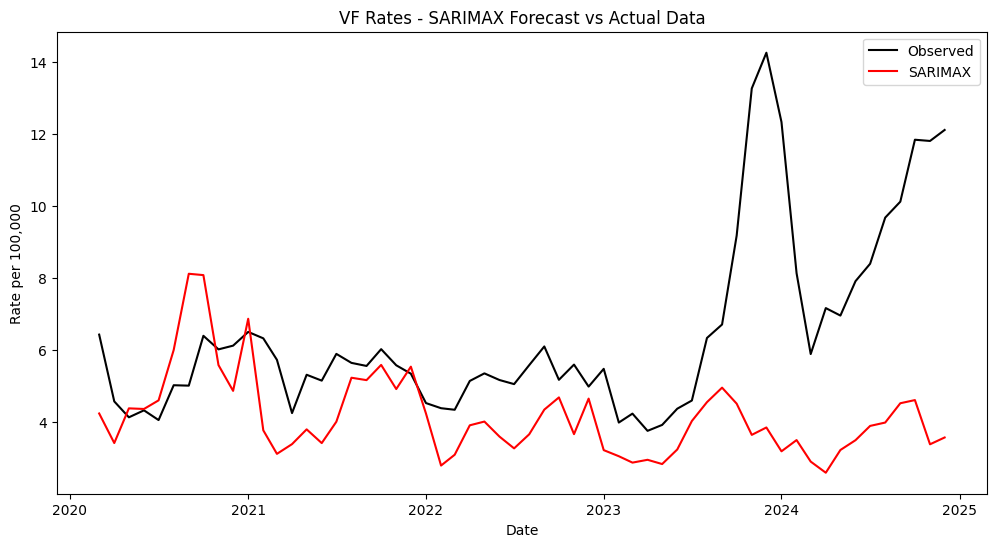

Model                           RMSE=3.61779   MAE=2.52883
{'RMSE': np.float64(3.6177894384745612), 'MAE': 2.5288345479743763}


In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test_original, label="Observed", color="black")
plt.plot(test_dates, y_pred_original, label="SARIMAX", color="red")

plt.title("VF Rates - SARIMAX Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

print(utils.compute_metrics(y_test_original, y_pred_original))

In [ ]:
# X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X_scaled, y)
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

test_dates = monthly_all_df["Year-Month"].iloc[split:]

In [ ]:
# auto ARIMA to find the best parameters
auto_model = auto_arima(y_train, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)
order = auto_model.order
seasonal_order = auto_model.seasonal_order

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.56 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-89.981, Time=0.10 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-118.904, Time=0.26 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-109.783, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-91.787, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-90.769, Time=0.12 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=-121.821, Time=3.56 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=4.57 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=-122.539, Time=0.70 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-118.773, Time=0.18 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.94 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.93 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-121.547, Time=0.79 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=-120

In [ ]:
# sarima model to predict VF rate

sarimax_model = SARIMAX(
    endog=y_train,
    trend='n',
    order=order,
    seasonal_order=seasonal_order
)

results = sarimax_model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      rate_per_100k   No. Observations:                  230
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 12)   Log Likelihood                  65.219
Date:                            Mon, 06 Jul 2026   AIC                           -124.438
Time:                                    19:21:31   BIC                           -114.137
Sample:                                         0   HQIC                          -120.282
                                            - 230                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.3082      0.066      4.691      0.000       0.179       0.437
ar.S.L24       0.1685      0.082   

In [ ]:
forecast = results.get_forecast(steps=len(y_test), exog=None)
y_pred = forecast.predicted_mean

# Convert preds back to original scale
y_pred_original = np.expm1(y_pred)

y_test_original = monthly_all_df['rate_per_100k'].iloc[split:]

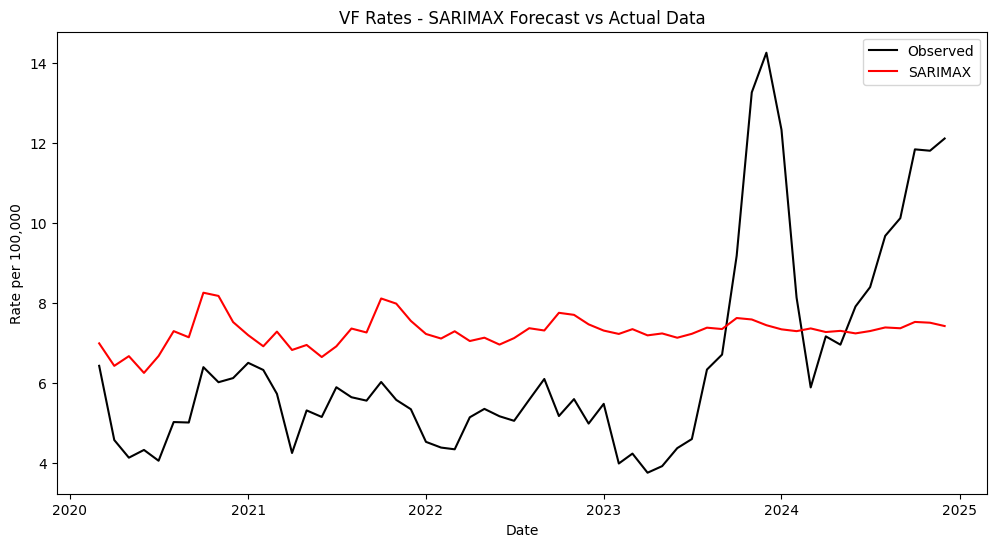

Model                           RMSE=2.56693   MAE=2.22581
{'RMSE': np.float64(2.5669267349036793), 'MAE': 2.2258091537376568}


In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test_original, label="Observed", color="black")
plt.plot(test_dates, y_pred_original, label="SARIMAX", color="red")

plt.title("VF Rates - SARIMAX Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

print(utils.compute_metrics(y_test_original, y_pred_original))